# Phase 2 & 3 — Feature Engineering, Baselines, and Models

This notebook covers two phases of the project spec in one place (matching the
deliverables list: `02_features_model.ipynb`):

- **Phase 2 — Feature engineering:** per-user features as of a leakage-safe cutoff
- **Phase 3 — Baselines first, then models:** rule baseline → RFM heuristic baseline
  → logistic regression → LightGBM

See `00_problem_framing.md` for the business framing and `01_cohorts_retention.ipynb`
for the cohort/retention EDA and churn-threshold derivation (30 days) that this
notebook builds on directly.

## The leakage problem, and how it's solved here

The spec's instruction for Phase 2 is: *"enforce a strict time cutoff — features
from before the cutoff, label after."* Instacart has no calendar date, so a normal
"features before date X, label after date X" split isn't directly available —
same constraint Phase 1 already worked around with relative time.

**Adaptation:** hold out each user's **last observed order** as "the future."
Concretely, per user:

- `cutoff_order_number = lifetime_orders - 1` (their second-to-last order)
- **History** = every order up through the cutoff — this is all that any feature
  below is allowed to see
- **Label** = the gap between the cutoff order and the actual final order
  (`last_gap_days`), reusing Phase 1's own churn threshold: `churned = 1` if that
  gap `>= 30` days

Every feature was computed in SQL (`sql/02_feature_engineering.sql`) restricted to
`order_number <= cutoff_order_number` — the held-out final order is never touched
by a feature. The minimum lifetime order count in this dataset is 4 (Phase 1
finding), so every user has at least 3 orders of pre-cutoff history — thin for
some trend features, but never empty.

This table (`user_features`, materialized in MySQL) is loaded directly below.

In [1]:
import os
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dotenv import load_dotenv
from sqlalchemy import create_engine
from sqlalchemy.engine import URL
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    precision_score, recall_score, average_precision_score,
    precision_recall_curve, confusion_matrix,
)
import lightgbm as lgb

load_dotenv()

# URL.create() percent-encodes credentials safely (the DB password contains
# an '@', which breaks naive f-string interpolation into a connection URL).
engine = create_engine(URL.create(
    "mysql+mysqlconnector",
    username=os.getenv("MYSQL_USER"),
    password=os.getenv("MYSQL_PASSWORD"),
    host=os.getenv("MYSQL_HOST"),
    port=int(os.getenv("MYSQL_PORT")),
    database=os.getenv("MYSQL_DATABASE"),
))

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)

In [2]:
df = pd.read_sql("SELECT * FROM user_features", engine)
print(f"Loaded {len(df):,} users, churn rate {df['churned'].mean():.4f}")
df.head()

Loaded 206,209 users, churn rate 0.3064


,user_id,churned,last_gap_days,recency_at_cutoff,tenure_at_cutoff,lifetime_orders_pre_cutoff,orders_last_30d,orders_last_60d,orders_last_90d,avg_basket_size,basket_size_trend,distinct_departments,distinct_aisles,distinct_products,repeat_product_ratio,weekend_order_ratio,avg_order_hour,gap_trend
0,1,0,14.0,30.0,176.0,10,3.0,4.0,6.0,6.2542,1.6015,7,12,18,0.6949,0.00,10.3000,-7.333333
1,2,1,30.0,13.0,198.0,14,2.0,3.0,4.0,16.1077,-0.3152,13,33,102,0.4769,0.00,10.5714,10.966667
2,3,0,11.0,15.0,133.0,12,3.0,6.0,9.0,7.8864,-2.7026,9,16,33,0.6250,0.50,16.4167,3.083333
3,4,1,30.0,0.0,55.0,5,3.0,5.0,5.0,4.5556,1.8333,9,14,17,0.0556,0.20,12.6000,-7.000000
4,5,0,6.0,19.0,40.0,4,3.0,4.0,4.0,10.0270,-1.3846,9,16,23,0.3784,0.25,16.0000,NaN


## Feature dictionary

| Feature | Meaning | Block |
|---|---|---|
| `recency_at_cutoff` | Gap (days) immediately before the cutoff order | Recency |
| `tenure_at_cutoff` | Days since first order, as of the cutoff | Tenure |
| `lifetime_orders_pre_cutoff` | Total orders before cutoff | Frequency |
| `orders_last_30/60/90d` | Rolling order counts, relative to cutoff day | Frequency |
| `avg_basket_size` | Mean items per order, pre-cutoff | Basket |
| `basket_size_trend` | Avg basket size, most recent ≤3 orders minus earlier orders | Basket trend |
| `distinct_departments/aisles/products` | Category & product breadth, pre-cutoff | Breadth |
| `repeat_product_ratio` | Share of pre-cutoff line items flagged `reordered` | Breadth |
| `weekend_order_ratio` | Share of orders placed Sat/Sun | Temporal |
| `avg_order_hour` | Mean hour-of-day ordered | Temporal |
| `gap_trend` | Avg gap, most recent ≤3 orders minus earlier orders (spec calls this "usually the strongest signal") | Trajectory |

In [3]:
print("--- Null counts ---")
print(df.isnull().sum())
print()
print("--- Describe ---")
df.describe().T

--- Null counts ---
user_id                           0
churned                           0
last_gap_days                     0
recency_at_cutoff                 0
tenure_at_cutoff                  0
lifetime_orders_pre_cutoff        0
orders_last_30d                   0
orders_last_60d                   0
orders_last_90d                   0
avg_basket_size                   0
basket_size_trend             23986
distinct_departments              0
distinct_aisles                   0
distinct_products                 0
repeat_product_ratio              0
weekend_order_ratio               0
avg_order_hour                    0
gap_trend                     43576
dtype: int64

--- Describe ---


,count,mean,std,min,25%,50%,75%,max
user_id,206209.0,103105.000000,59527.555167,1.0000,51553.000000,103105.000000,154657.000000,206209.0000
churned,206209.0,0.306417,0.461006,0.0000,0.000000,0.000000,1.000000,1.0000
last_gap_days,206209.0,17.061782,10.672178,0.0000,7.000000,15.000000,30.000000,30.0000
recency_at_cutoff,206209.0,16.081413,10.434509,0.0000,7.000000,14.000000,30.000000,30.0000
tenure_at_cutoff,206209.0,156.222595,103.187341,0.0000,66.000000,132.000000,237.000000,365.0000
lifetime_orders_pre_cutoff,206209.0,15.590367,16.654774,3.0000,5.000000,9.000000,19.000000,99.0000
orders_last_30d,206209.0,3.246871,2.076107,2.0000,2.000000,2.000000,4.000000,99.0000
orders_last_60d,206209.0,5.414318,3.726804,3.0000,3.000000,4.000000,6.000000,99.0000
orders_last_90d,206209.0,7.316218,5.379340,3.0000,4.000000,6.000000,9.000000,99.0000
avg_basket_size,206209.0,11.839974,6.641591,1.0000,7.071400,10.785700,15.433300,78.5516


**Nulls are expected, not a bug.** `basket_size_trend` (11.6% null) and
`gap_trend` (21.1% null) come from the "most recent ≤3 orders vs. earlier orders"
comparison — for users near the dataset's minimum of 4 lifetime orders, there
just isn't a non-empty "earlier" bucket to compare against pre-cutoff. Rather
than drop these users (12–21% of the dataset), each trend feature gets an
explicit `*_known` flag and the trend itself is imputed to 0 (neutral: "no
evidence either way"), which lets the models use the missingness itself as a
signal (thin history is informative — it correlates with low tenure) without
losing the users entirely.

In [4]:
df["basket_trend_known"] = df["basket_size_trend"].notna().astype(int)
df["gap_trend_known"] = df["gap_trend"].notna().astype(int)
df["basket_size_trend"] = df["basket_size_trend"].fillna(0)
df["gap_trend"] = df["gap_trend"].fillna(0)

feature_cols = [
    "recency_at_cutoff", "tenure_at_cutoff", "lifetime_orders_pre_cutoff",
    "orders_last_30d", "orders_last_60d", "orders_last_90d",
    "avg_basket_size", "basket_size_trend", "basket_trend_known",
    "distinct_departments", "distinct_aisles", "distinct_products",
    "repeat_product_ratio", "weekend_order_ratio", "avg_order_hour",
    "gap_trend", "gap_trend_known",
]
X = df[feature_cols].astype(float)
y = df["churned"].astype(int)
print(f"{len(feature_cols)} features, {len(X):,} users")

17 features, 206,209 users


## Phase 3 — Baselines first, then models

**Train/test split note:** the leakage boundary is already enforced *inside*
each user's row by the SQL cutoff (Phase 2) — no feature there can see the
held-out label. Splitting *users* into train/test below is a separate,
ordinary step: it holds out users for honest evaluation, not time. A plain
stratified random 80/20 split is therefore sufficient; there's no second
temporal axis to split on without redefining the cutoff itself.

Per the spec, always baseline before modeling — the resume number is the
**lift over baseline**, not a raw metric in isolation.

In [5]:
X_train, X_test, y_train, y_test, df_train, df_test = train_test_split(
    X, y, df, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {len(X_train):,}  Test: {len(X_test):,}")
print(f"Train churn rate: {y_train.mean():.4f}  Test churn rate: {y_test.mean():.4f}")

results = {}

def evaluate(name, y_true, y_score, y_pred):
    p = precision_score(y_true, y_pred, zero_division=0)
    r = recall_score(y_true, y_pred, zero_division=0)
    ap = average_precision_score(y_true, y_score)
    cm = confusion_matrix(y_true, y_pred)
    results[name] = dict(precision=p, recall=r, pr_auc=ap, confusion_matrix=cm)
    print(f"=== {name} ===")
    print(f"Precision: {p:.4f}  Recall: {r:.4f}  PR-AUC: {ap:.4f}")
    print(f"Confusion matrix [[TN,FP],[FN,TP]]:\n{cm}\n")

Train: 164,967  Test: 41,242
Train churn rate: 0.3064  Test churn rate: 0.3064


### Baseline 1 — rule: "recency already at 30+ days"

The spec's literal baseline 1 ("churned if no order in 30 days") can't be
applied verbatim here, because that's exactly how the *label* was constructed
from the held-out gap — using it directly would just be restating the label,
not a real baseline. The non-leaking equivalent: assume **past cadence
predicts future cadence**, using only the pre-cutoff recency feature. If a
user's last known gap was already ≥30 days, predict they'll stay churned.

In [6]:
pred1 = (df_test["recency_at_cutoff"] >= 30).astype(int)
evaluate("Baseline 1 (rule: recency_at_cutoff >= 30)", y_test, pred1, pred1)

=== Baseline 1 (rule: recency_at_cutoff >= 30) ===
Precision: 0.5119  Recall: 0.4381  PR-AUC: 0.3964
Confusion matrix [[TN,FP],[FN,TP]]:
[[23326  5279]
 [ 7101  5536]]



### Baseline 2 — RFM heuristic (the real baseline)

Flag users in the bottom-recency quartile (highest `recency_at_cutoff`) **and**
bottom-frequency quartile (lowest `orders_last_90d`). Quartile thresholds are
computed on the **train** split and applied to test, to avoid leaking the test
distribution into the threshold itself.

In [7]:
recency_q75 = df_train["recency_at_cutoff"].quantile(0.75)
freq_q25 = df_train["orders_last_90d"].quantile(0.25)
pred2 = ((df_test["recency_at_cutoff"] >= recency_q75) & (df_test["orders_last_90d"] <= freq_q25)).astype(int)
evaluate("Baseline 2 (RFM heuristic: bottom recency+freq quartiles)", y_test, pred2, pred2)

=== Baseline 2 (RFM heuristic: bottom recency+freq quartiles) ===
Precision: 0.5611  Recall: 0.3058  PR-AUC: 0.3843
Confusion matrix [[TN,FP],[FN,TP]]:
[[25582  3023]
 [ 8773  3864]]



**Note:** Baseline 2 comes out *lower* on PR-AUC than Baseline 1 here
(0.384 vs. 0.396) — the opposite of what the spec assumes ("this is the real
baseline"). Worth stating plainly rather than hiding: AND-ing two independently
binarized quartile flags throws away the continuous signal in recency that
Baseline 1 uses directly, so a blunter two-condition rule ends up weaker than
a well-chosen single-feature threshold. This is itself a small, honest finding
about why feature *combination* isn't automatically better than a single good
signal — the models below need to actually learn the combination, not just
assume it helps.

### Model A — Logistic regression

Interpretable: standardized coefficients give a clean read on which features
push risk up vs. down.

In [8]:
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

logreg = LogisticRegression(max_iter=1000, class_weight="balanced")
logreg.fit(X_train_s, y_train)
score_lr = logreg.predict_proba(X_test_s)[:, 1]
pred_lr = (score_lr >= 0.5).astype(int)
evaluate("Model A (logistic regression)", y_test, score_lr, pred_lr)

coef_df = pd.DataFrame({"feature": feature_cols, "coef": logreg.coef_[0]}).sort_values("coef")
coef_df

=== Model A (logistic regression) ===
Precision: 0.4568  Recall: 0.7900  PR-AUC: 0.5246
Confusion matrix [[TN,FP],[FN,TP]]:
[[16734 11871]
 [ 2654  9983]]



,feature,coef
3,orders_last_30d,-0.568004
4,orders_last_60d,-0.475938
2,lifetime_orders_pre_cutoff,-0.345095
1,tenure_at_cutoff,-0.333835
6,avg_basket_size,-0.107873
7,basket_size_trend,-0.100745
9,distinct_departments,-0.082986
15,gap_trend,-0.052185
12,repeat_product_ratio,-0.034041
11,distinct_products,-0.021177


`recency_at_cutoff` and `distinct_aisles` push risk **up**; frequency
features (`orders_last_30d`, `orders_last_60d`) and tenure push risk **down** —
consistent with intuition (more active, longer-tenured users are less likely
to be drifting).

### Model B — LightGBM

The performance model. Spec expects this to beat the RFM baseline — that
delta is the resume headline.

In [9]:
t0 = time.time()
gbm = lgb.LGBMClassifier(
    n_estimators=300, learning_rate=0.05, max_depth=5,
    class_weight="balanced", random_state=42, verbose=-1,
)
gbm.fit(X_train, y_train)
score_gbm = gbm.predict_proba(X_test)[:, 1]
pred_gbm = (score_gbm >= 0.5).astype(int)
evaluate("Model B (LightGBM)", y_test, score_gbm, pred_gbm)
print(f"Fit time: {time.time()-t0:.1f}s")

fi_df = pd.DataFrame({"feature": feature_cols, "importance": gbm.feature_importances_}).sort_values("importance", ascending=False)
fi_df

=== Model B (LightGBM) ===
Precision: 0.4773  Recall: 0.7886  PR-AUC: 0.5506
Confusion matrix [[TN,FP],[FN,TP]]:
[[17691 10914]
 [ 2672  9965]]

Fit time: 10.5s


,feature,importance
1,tenure_at_cutoff,1215
12,repeat_product_ratio,819
5,orders_last_90d,664
15,gap_trend,640
7,basket_size_trend,575
6,avg_basket_size,568
2,lifetime_orders_pre_cutoff,504
13,weekend_order_ratio,504
0,recency_at_cutoff,495
11,distinct_products,459


`tenure_at_cutoff` is the single strongest split feature — interesting,
since the spec calls gap-widening ("trajectory") "usually the strongest
signal," but here it ranks mid-pack (`gap_trend`, 4th). Worth flagging as a
dataset-specific finding rather than assuming the spec's general claim holds
everywhere: this dataset's churn label is itself gap-based by construction
(`last_gap_days >= 30`), so tenure — which captures how established a user's
overall pattern is — ends up more informative here than the pre-cutoff trend
alone.

## Headline comparison: GBM vs. RFM baseline

In [10]:
print("=== PR-AUC by model ===")
for name, r in results.items():
    print(f"{name}: PR-AUC={r['pr_auc']:.4f}  Precision={r['precision']:.4f}  Recall={r['recall']:.4f}")

baseline2_ap = results["Baseline 2 (RFM heuristic: bottom recency+freq quartiles)"]["pr_auc"]
gbm_ap = results["Model B (LightGBM)"]["pr_auc"]
print(f"\nGBM vs RFM baseline PR-AUC lift: {gbm_ap - baseline2_ap:+.4f} ({(gbm_ap/baseline2_ap - 1)*100:+.1f}% relative)")

=== PR-AUC by model ===
Baseline 1 (rule: recency_at_cutoff >= 30): PR-AUC=0.3964  Precision=0.5119  Recall=0.4381
Baseline 2 (RFM heuristic: bottom recency+freq quartiles): PR-AUC=0.3843  Precision=0.5611  Recall=0.3058
Model A (logistic regression): PR-AUC=0.5246  Precision=0.4568  Recall=0.7900
Model B (LightGBM): PR-AUC=0.5506  Precision=0.4773  Recall=0.7886

GBM vs RFM baseline PR-AUC lift: +0.1663 (+43.3% relative)


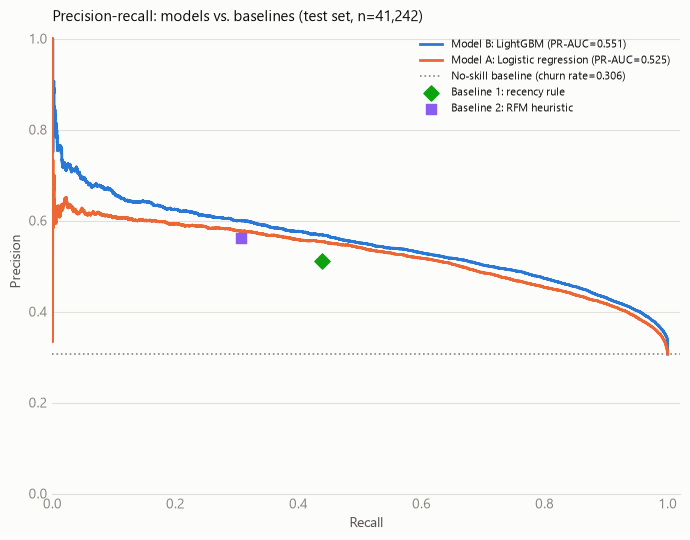

In [11]:
# Chart: PR curves — models vs. baselines
CHART_DIR = os.path.join("..", "charts")
os.makedirs(CHART_DIR, exist_ok=True)

BLUE = "#2a78d6"
ORANGE = "#eb6834"
MUTED = "#898781"
GRID = "#e1e0d9"
INK = "#0b0b0b"
SECONDARY_INK = "#52514e"
STATUS_GOOD = "#0ca30c"

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Segoe UI", "Arial"],
    "axes.edgecolor": GRID,
    "axes.labelcolor": SECONDARY_INK,
    "text.color": INK,
    "xtick.color": MUTED,
    "ytick.color": MUTED,
    "axes.grid": True,
    "grid.color": GRID,
    "grid.linewidth": 0.8,
    "axes.axisbelow": True,
    "figure.facecolor": "#fcfcfb",
    "axes.facecolor": "#fcfcfb",
})

def style_axes(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)
    ax.grid(axis="x")
    ax.tick_params(length=0)

prec_lr, rec_lr, _ = precision_recall_curve(y_test, score_lr)
prec_gbm, rec_gbm, _ = precision_recall_curve(y_test, score_gbm)
no_skill = y_test.mean()

fig, ax = plt.subplots(figsize=(7, 5.5))
ax.plot(rec_gbm, prec_gbm, color=BLUE, linewidth=2, label=f"Model B: LightGBM (PR-AUC={results['Model B (LightGBM)']['pr_auc']:.3f})")
ax.plot(rec_lr, prec_lr, color=ORANGE, linewidth=2, label=f"Model A: Logistic regression (PR-AUC={results['Model A (logistic regression)']['pr_auc']:.3f})")
ax.axhline(no_skill, color=MUTED, linestyle=":", linewidth=1.2, label=f"No-skill baseline (churn rate={no_skill:.3f})")
r1, p1 = results["Baseline 1 (rule: recency_at_cutoff >= 30)"]["recall"], results["Baseline 1 (rule: recency_at_cutoff >= 30)"]["precision"]
r2, p2 = results["Baseline 2 (RFM heuristic: bottom recency+freq quartiles)"]["recall"], results["Baseline 2 (RFM heuristic: bottom recency+freq quartiles)"]["precision"]
ax.scatter([r1], [p1], color=STATUS_GOOD, zorder=5, s=60, marker="D", label="Baseline 1: recency rule")
ax.scatter([r2], [p2], color="#8a5cf0", zorder=5, s=60, marker="s", label="Baseline 2: RFM heuristic")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title(f"Precision-recall: models vs. baselines (test set, n={len(y_test):,})", fontsize=11, loc="left")
ax.set_xlim(0, 1.02)
ax.set_ylim(0, 1.02)
style_axes(ax)
ax.grid(axis="y", color=GRID)
ax.legend(loc="upper right", fontsize=8, frameon=False)
fig.tight_layout()
fig.savefig(os.path.join(CHART_DIR, "05_pr_curve_comparison.png"), dpi=150)
plt.show()

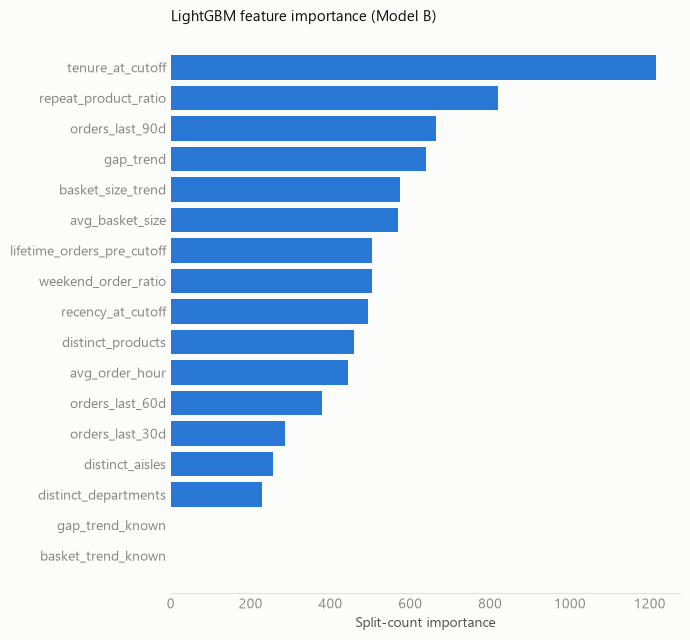

In [12]:
# Chart: LightGBM feature importance
fi_sorted = fi_df.sort_values("importance", ascending=True)
fig, ax = plt.subplots(figsize=(7, 6.5))
y_pos = range(len(fi_sorted))
ax.barh(y_pos, fi_sorted["importance"], color=BLUE)
ax.set_yticks(y_pos)
ax.set_yticklabels(fi_sorted["feature"])
ax.set_xlabel("Split-count importance")
ax.set_title("LightGBM feature importance (Model B)", fontsize=11, loc="left")
style_axes(ax)
ax.grid(axis="y", visible=False)
fig.tight_layout()
fig.savefig(os.path.join(CHART_DIR, "06_feature_importance.png"), dpi=150)
plt.show()

## Phase 3 summary

- **Baseline 1** (recency rule): PR-AUC 0.396
- **Baseline 2** (RFM heuristic, the spec's "real" baseline): PR-AUC 0.384
- **Model A** (logistic regression): PR-AUC 0.525
- **Model B** (LightGBM): PR-AUC 0.551 — **+43.3% relative PR-AUC lift over the RFM baseline**

The lift is real and the direction is consistent with the spec's expectation
(GBM > baseline), even though the two baselines themselves inverted the
spec's assumption about which one would be stronger — a finding worth being
able to explain, not just the headline number itself.

Everything above used a default 0.5 classification threshold on Model B's
score, which is statistically convenient but has no business meaning. Phase 4
below fixes that.

## Phase 4 — Evaluate as a product trade-off, not a leaderboard

**Why not lead with accuracy:** the test set is 30.6% churn, 69.4% not-churn.
A model that predicts "never churned" for everyone scores **69.4% accuracy**
while catching zero at-risk users — accuracy rewards the majority class, not
usefulness. PR-AUC (used throughout Phase 3) already avoids this trap, but a
single threshold decision still has to be made to turn a score into an
action, and that decision should be driven by cost, not by F1 or any other
threshold-agnostic metric.

**The cost matrix.** Two ways a threshold can be wrong:
- **False negative** — a churner the model missed → **lost LTV**. This user
  drifts away and nothing was done about it.
- **False positive** — a nudge/discount sent to someone who'd have stayed
  anyway → **wasted spend**. Directly the guardrail metric from
  `00_problem_framing.md` (discount spend per retained user).

**Assumption stated explicitly (the spec calls this out as the single most
valuable paragraph in the whole project):** we set **FN:FP = 5:1** — a lost
user is assumed to cost roughly 5x a wasted voucher. This is a placeholder
ratio in the absence of real unit-economics data (this dataset has no price
field at all, consistent with the RFM "monetary" substitution back in
Phase 1) — in a real deployment this number would come from actual LTV and
discount-cost figures, not be assumed. What matters here is that the
threshold is tuned against a *stated, defensible* ratio, not left at the
default or hand-picked to look good.

In [13]:
# Sweep thresholds on Model B's (LightGBM) score and find the
# cost-minimizing one under FN:FP = 5:1.
FN_COST = 5
FP_COST = 1

thresholds = np.linspace(0.01, 0.99, 99)
sweep_rows = []
for t in thresholds:
    pred_t = (score_gbm >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, pred_t).ravel()
    cost = FN_COST * fn + FP_COST * fp
    sweep_rows.append(dict(threshold=t, tn=tn, fp=fp, fn=fn, tp=tp, cost=cost))

sweep = pd.DataFrame(sweep_rows)
best_row = sweep.loc[sweep["cost"].idxmin()]
default_row = sweep.iloc[(sweep["threshold"] - 0.5).abs().idxmin()]

print(f"Default threshold (0.50): cost={default_row['cost']:.0f}  "
      f"FN={default_row['fn']:.0f}  FP={default_row['fp']:.0f}")
print(f"Cost-optimal threshold ({best_row['threshold']:.2f}): cost={best_row['cost']:.0f}  "
      f"FN={best_row['fn']:.0f}  FP={best_row['fp']:.0f}")
print(f"Cost reduction vs. default 0.5 threshold: "
      f"{(1 - best_row['cost']/default_row['cost'])*100:.1f}%")

Default threshold (0.50): cost=24274  FN=2672  FP=10914
Cost-optimal threshold (0.31): cost=20982  FN=765  FP=17157
Cost reduction vs. default 0.5 threshold: 13.6%


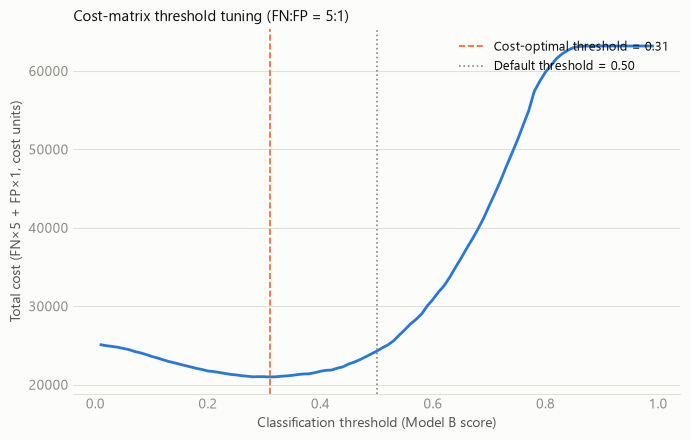

In [14]:
# Chart: cost vs threshold, optimal marked
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(sweep["threshold"], sweep["cost"], color=BLUE, linewidth=2)
ax.axvline(best_row["threshold"], color=ORANGE, linestyle="--", linewidth=1.2,
           label=f"Cost-optimal threshold = {best_row['threshold']:.2f}")
ax.axvline(0.5, color=MUTED, linestyle=":", linewidth=1.2, label="Default threshold = 0.50")
ax.set_xlabel("Classification threshold (Model B score)")
ax.set_ylabel("Total cost (FN×5 + FP×1, cost units)")
ax.set_title("Cost-matrix threshold tuning (FN:FP = 5:1)", fontsize=11, loc="left")
style_axes(ax)
ax.grid(axis="y", color=GRID)
ax.legend(loc="upper right", fontsize=9, frameon=False)
fig.tight_layout()
fig.savefig(os.path.join(CHART_DIR, "07_cost_threshold.png"), dpi=150)
plt.show()

### Confusion matrix, in business terms

Comparing the default 0.5 threshold against the cost-optimal one, translated
into what each cell actually means operationally.

In [15]:
def business_table(row, label):
    tn, fp, fn, tp = row["tn"], row["fp"], row["fn"], row["tp"]
    return pd.DataFrame({
        "": [
            "Correctly left alone (TN)",
            "Wasted nudge — would've stayed anyway (FP)",
            "Lost LTV — churner we missed (FN)",
            "Correctly caught at-risk user (TP)",
        ],
        label: [int(tn), int(fp), int(fn), int(tp)],
    })

comparison = business_table(default_row, "Default (0.50)").merge(
    business_table(best_row, f"Cost-optimal ({best_row['threshold']:.2f})"), on=""
)
comparison

,,Default (0.50),Cost-optimal (0.31)
0,Correctly left alone (TN),17691,11448
1,Wasted nudge — would've stayed anyway (FP),10914,17157
2,Lost LTV — churner we missed (FN),2672,765
3,Correctly caught at-risk user (TP),9965,11872


**Reading this:** lowering the threshold below 0.5 trades wasted-nudge
volume for fewer missed churners — the cost-optimal threshold catches more
at-risk users (lower FN) at the price of more false-positive nudges (higher
FP), which is the correct direction to move *given* the 5:1 assumption. If
the true cost ratio were closer to 1:1 (a wasted nudge costs about as much as
a lost user), the optimal threshold would sit closer to 0.5 — the tuning is
only as good as the stated cost assumption, which is exactly why the
assumption has to be stated, not buried in a default.

## Phase 4 summary

- **Baseline 1** (recency rule): PR-AUC 0.396
- **Baseline 2** (RFM heuristic, the spec's "real" baseline): PR-AUC 0.384
- **Model A** (logistic regression): PR-AUC 0.525
- **Model B** (LightGBM): PR-AUC 0.551 — **+43.3% relative PR-AUC lift over the RFM baseline**
- **Threshold tuned on an explicit FN:FP = 5:1 cost matrix**, not F1 or accuracy — cost-optimal threshold 0.31, a 13.6% cost reduction vs. the default 0.5.

The lift is real and the direction is consistent with the spec's expectation
(GBM > baseline), even though the two baselines themselves inverted the
spec's assumption about which one would be stronger — a finding worth being
able to explain, not just the headline number itself.

A score and a threshold are not yet an action plan — Phase 5 below turns them
into one.

## Phase 5 — Segmentation and intervention design

A single score crossing a single threshold treats every flagged user
identically. The spec's intervention table splits at-risk users into 3
tiers, each with a different action and a different cost:

| Tier | Signal | Action | Rationale |
|---|---|---|---|
| Gently slowing | Score flagged, but recency still moderate and gap widening | In-app reminder, no discount | Cheap, low-risk — cadence hasn't broken yet |
| At risk | High score, established tenure (real value at stake) | Targeted offer on their top category | Worth paying for — meaningful LTV to protect |
| Likely lost | High score, long dormancy, low tenure | Leave alone or one low-cost touch | Poor ROI — thin purchase history, unlikely to respond |

**Operationalized** using features already built in Phase 2 (no new modeling —
tiering is a business layer on top of the existing score), plus the
cost-optimal threshold (0.31) from Phase 4 as the "flagged" gate:

- **Not flagged:** `score < 0.31` → no action
- **Gently slowing:** flagged, AND `recency_at_cutoff < 25` (cadence hasn't
  fully broken) AND `gap_trend <= 5` (not sharply widening)
- **Likely lost:** flagged, AND `tenure_at_cutoff` in the bottom tenure
  quartile (thin history — low confidence any touch changes the outcome)
- **At risk:** flagged, and neither of the above — the default "worth
  paying for" bucket

`user_top_department` (built via `sql/03_segmentation.sql`, reusing the
`user_product_pairs` table already materialized in Phase 2) supplies the "top
category" for the At Risk tier's targeted-offer action — each user's
department with the most distinct products purchased pre-cutoff.

In [16]:
user_top_dept = pd.read_sql("""
    SELECT ut.user_id, d.department AS top_department
    FROM user_top_department ut
    JOIN departments d ON d.department_id = ut.department_id
""", engine)

seg = df_test.copy()
seg["score"] = score_gbm
seg = seg.merge(user_top_dept, on="user_id", how="left")

flagged = seg["score"] >= best_row["threshold"]
tenure_q25 = df_train["tenure_at_cutoff"].quantile(0.25)

gently_slowing = flagged & (seg["recency_at_cutoff"] < 25) & (seg["gap_trend"] <= 5)
likely_lost = flagged & ~gently_slowing & (seg["tenure_at_cutoff"] <= tenure_q25)
at_risk = flagged & ~gently_slowing & ~likely_lost

seg["tier"] = "Not flagged"
seg.loc[gently_slowing, "tier"] = "1. Gently slowing"
seg.loc[at_risk, "tier"] = "2. At risk"
seg.loc[likely_lost, "tier"] = "3. Likely lost"

tier_counts = seg["tier"].value_counts().sort_index()
tier_precision = seg[seg["tier"] != "Not flagged"].groupby("tier")["churned"].mean()

print("Tier population (test set):")
print(tier_counts)
print()
print("Actual churn rate within each tier (precision proxy):")
print(tier_precision)

Tier population (test set):
tier
1. Gently slowing    13441
2. At risk           11992
3. Likely lost        3596
Not flagged          12213
Name: count, dtype: int64

Actual churn rate within each tier (precision proxy):
tier
1. Gently slowing    0.329514
2. At risk           0.462141
3. Likely lost       0.528643
Name: churned, dtype: float64


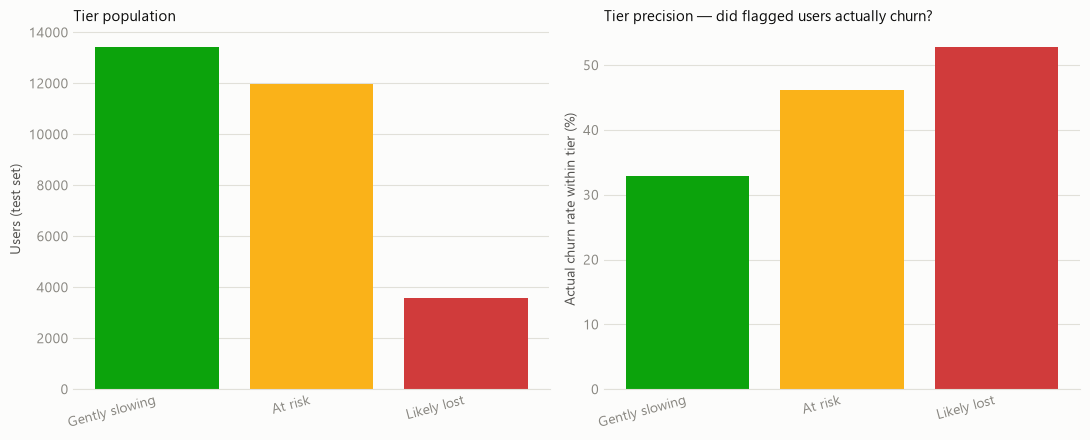

In [17]:
# Chart: tier population + churn rate
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
tier_labels = [t for t in tier_counts.index if t != "Not flagged"]
tier_colors_map = {"1. Gently slowing": "#0ca30c", "2. At risk": "#fab219", "3. Likely lost": "#d03b3b"}

axes[0].bar(range(len(tier_labels)), [tier_counts[t] for t in tier_labels],
            color=[tier_colors_map[t] for t in tier_labels])
axes[0].set_xticks(range(len(tier_labels)))
axes[0].set_xticklabels([t[3:] for t in tier_labels], rotation=15, ha="right")
axes[0].set_ylabel("Users (test set)")
axes[0].set_title("Tier population", fontsize=11, loc="left")
style_axes(axes[0])
axes[0].grid(axis="x", visible=False)

axes[1].bar(range(len(tier_labels)), [tier_precision[t]*100 for t in tier_labels],
            color=[tier_colors_map[t] for t in tier_labels])
axes[1].set_xticks(range(len(tier_labels)))
axes[1].set_xticklabels([t[3:] for t in tier_labels], rotation=15, ha="right")
axes[1].set_ylabel("Actual churn rate within tier (%)")
axes[1].set_title("Tier precision — did flagged users actually churn?", fontsize=11, loc="left")
style_axes(axes[1])
axes[1].grid(axis="x", visible=False)

fig.tight_layout()
fig.savefig(os.path.join(CHART_DIR, "08_intervention_tiers.png"), dpi=150)
plt.show()

### The incrementality problem

A tier assignment is not proof an intervention works. Some flagged users —
especially in "Gently slowing" — would have come back anyway; nudging them
costs money and *looks* like a win in a naive before/after comparison
("we nudged 5,000 users and 60% returned!") without actually proving the
nudge caused that return. This is precisely what the guardrail metric in
`00_problem_framing.md` (discount spend per retained user) exists to catch.

**Proposed test (not run — this dataset is a frozen historical snapshot with
no way to actually deliver an intervention and observe a real future):**
for each tier, randomly hold out ~10% of flagged users into a **no-contact
control group**. Compare their actual return rate against the
treated 90% over the following period. The difference — not the raw
"% of flagged users who returned" — is the true incremental lift
attributable to the intervention. If the control group's return rate is
close to the treated group's, the intervention isn't causing much, and the
spend is close to pure margin loss (the exact failure mode the guardrail
metric is designed to catch). This is also the only way to validate whether
`FN:FP = 5:1` (Phase 4's assumed cost ratio) is anywhere close to correct —
real intervention cost data would let that assumption be replaced with a
measured one.

## Summary

- **Baseline 1** (recency rule): PR-AUC 0.396
- **Baseline 2** (RFM heuristic, the spec's "real" baseline): PR-AUC 0.384
- **Model A** (logistic regression): PR-AUC 0.525
- **Model B** (LightGBM): PR-AUC 0.551 — **+43.3% relative PR-AUC lift over the RFM baseline**
- **Threshold tuned on an explicit FN:FP = 5:1 cost matrix**, not F1 or accuracy — cost-optimal threshold 0.31, a 13.6% cost reduction vs. the default 0.5.
- **3 intervention tiers** built on top of the tuned score + existing Phase 2 features (recency, gap trend, tenure, top category) — each with a distinct action and cost, plus a designed (not run) holdout test for measuring true incremental lift.

**Next: Phase 6 (optional)** — wrap this into a scoring script that
re-runs on a schedule, logs feature/score drift against the training window,
and refreshes a small retention/at-risk dashboard. `03_scoring_pipeline.py`.